<a href="https://colab.research.google.com/github/25wh1a0534-coder/NASSCOM/blob/main/U6_Probability_Statistics_Part1_Lab_(5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)




total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [ ]:

print('Mean total_bill:', round(df['total_bill'].mean(), 2))
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [ ]:
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value

Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


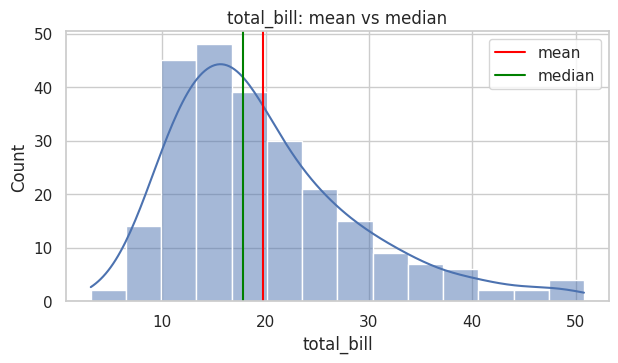

In [ ]:
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()


In [ ]:
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [ ]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# Skewness: > 0 means a right tail, < 0 a left tail, ~0 symmetric
print('\nSkewness:', round(col.skew(), 3))


min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


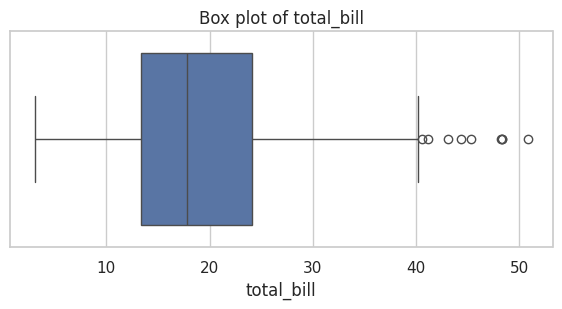

In [ ]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

In [ ]:

# .corr() returns a matrix of correlations in the range -1 .. +1
corr = df.corr(numeric_only=True)
print(corr.round(2))

# correlation is NOT causation, and it only measures LINEAR relationships
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')


            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


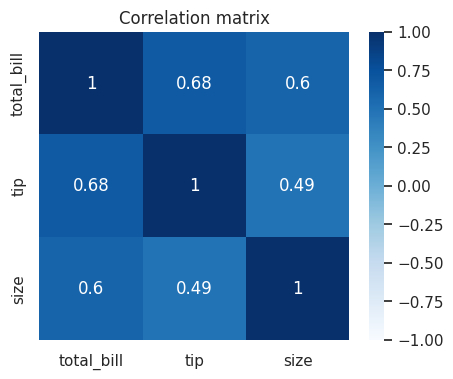

In [ ]:
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

In [ ]:
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)

Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: ['sex', 'smoker', 'day', 'time']


In [ ]:
print(df['tip'].mean())
print("Mean of tip:", df['tip'].mean())

2.99827868852459
Mean of tip: 2.99827868852459


In [ ]:
print(df['sex'].value_counts())

sex
Male      157
Female     87
Name: count, dtype: int64


In [ ]:
print("Mean:", df['tip'].mean())
print("Median:", df['tip'].median())
print("Mode:", df['tip'].mode()[0])

Mean: 2.99827868852459
Median: 2.9
Mode: 2.0


In [ ]:
mean = df['tip'].mean()
median = df['tip'].median()

if mean > median:
    print("The tip column is right-skewed.")
else:
    print("The tip column is not right-skewed.")

The tip column is right-skewed.


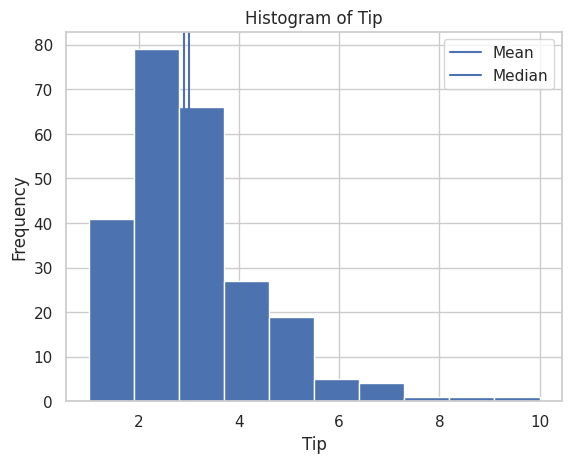

In [ ]:
import matplotlib.pyplot as plt

mean = df['tip'].mean()
median = df['tip'].median()

plt.hist(df['tip'], bins=10)
plt.axvline(mean, label='Mean')
plt.axvline(median, label='Median')

plt.xlabel('Tip')
plt.ylabel('Frequency')
plt.title('Histogram of Tip')
plt.legend()
plt.show()

In [ ]:
print("Range:", df['tip'].max() - df['tip'].min())
print("Variance:", df['tip'].var())
print("Standard Deviation:", df['tip'].std())

Range: 9.0
Variance: 1.9144546380624725
Standard Deviation: 1.3836381890011826


In [ ]:
Q1 = df['tip'].quantile(0.25)
Q3 = df['tip'].quantile(0.75)
IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 2.0
Q3: 3.5625
IQR: 1.5625


In [ ]:
# IQR is the most robust measure of spread because it is less affected
# by outliers than range, variance, and standard deviation.

In [ ]:
print(df['tip'].describe()[['min', '25%', '50%', '75%', 'max']])

min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64


In [ ]:
skewness = df['tip'].skew()

print("Skewness:", skewness)

# If skewness > 0, the data leans to the right (right-skewed).
# If skewness < 0, the data leans to the left (left-skewed).

Skewness: 1.4654510370979401


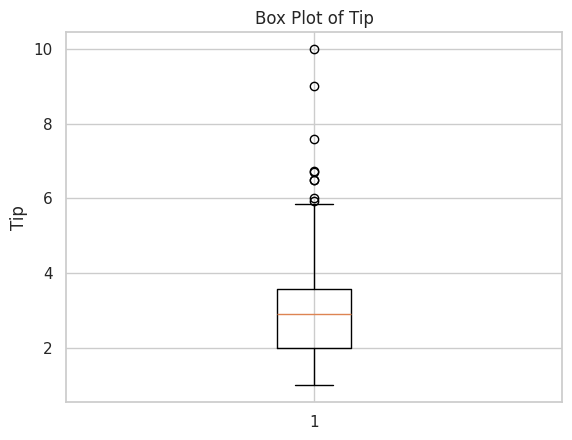

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df['tip'])
plt.ylabel('Tip')
plt.title('Box Plot of Tip')
plt.show()

In [ ]:
corr_matrix = df.corr(numeric_only=True)

print(corr_matrix.round(2))

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


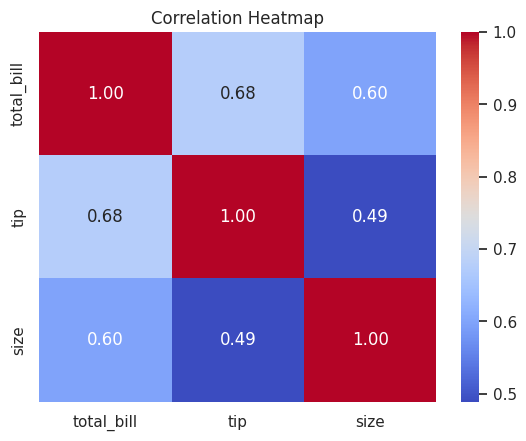

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
print(df.describe())

# Insights:
# 1. The column with the largest standard deviation is the most spread out.
# 2. The pair with the correlation value closest to +1 or -1 is the most strongly correlated.
# 3. If mean is greater than median, the column is right-skewed;
#    if mean is less than median, it is left-skewed.

       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000
